# EDA: E-CUP Matching (Ozon)

Разведка данных задачи матчинга товаров.
Файлы:
- `items.parquet` — все товары (~13.4M): `id, name, attributes, category`
- `items_human.parquet` — товары из ручной разметки (~711k)
- `matches.parquet` — пары с ручной разметкой (~366k), колонки `id1, id2, target`
- `matches_llm.parquet` — пары с LLM-разметкой (~11.2M)

## 0. Настройки и загрузка

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

DATA = '..'  # путь к данным (ноутбук лежит в notebooks/)

In [2]:
# Схемы без полной загрузки (файлы большие)
for f in ['items.parquet', 'items_human.parquet', 'matches.parquet', 'matches_llm.parquet']:
    pf = pq.ParquetFile(f'{DATA}/{f}')
    print(f'\n=== {f} | rows: {pf.metadata.num_rows:,} ===')
    print(pf.schema_arrow)


=== items.parquet | rows: 13,397,761 ===
id: int64
name: large_string
attributes: large_string
category: large_string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 714

=== items_human.parquet | rows: 711,304 ===
id: int64
name: large_string
attributes: large_string
category: large_string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 712

=== matches.parquet | rows: 365,654 ===
id1: int64
id2: int64
target: double
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 598

=== matches_llm.parquet | rows: 11,187,780 ===
id1: int64
id2: int64
target: double
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 600


## 1. Пары: ручная разметка

In [3]:
matches = pd.read_parquet(f'{DATA}/matches.parquet')
print(matches.shape)
matches.head()

(365654, 3)


,id1,id2,target
0,32,188978721454,0.0
1,34,197568543106,0.0
2,37,661425040668,0.0
3,97,274877917548,0.0
4,154,283467899529,0.0


target
0.0    271764
1.0     93890
Name: count, dtype: int64

Доля дубликатов: 0.2568


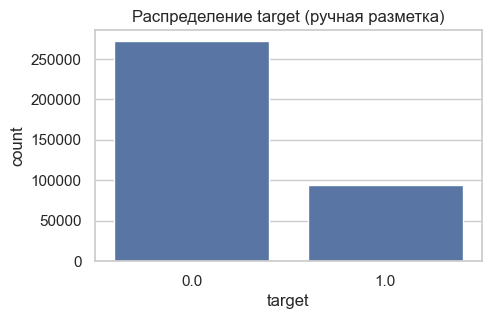

In [4]:
# Распределение таргета
print(matches['target'].value_counts(dropna=False))
print('\nДоля дубликатов:', matches['target'].mean().round(4))

fig, ax = plt.subplots(figsize=(5,3))
sns.countplot(x=matches['target'], ax=ax)
ax.set_title('Распределение target (ручная разметка)')
plt.show()

In [5]:
# Есть ли пересечения пар между собой / дубликаты пар?
print('Уникальных пар:', len(matches.drop_duplicates(['id1','id2'])))
print('id1 == id2:', (matches['id1'] == matches['id2']).sum())
print('Пересечение id1/id2 множеств:', len(set(matches['id1']) & set(matches['id2'])))

Уникальных пар: 365654
id1 == id2: 0
Пересечение id1/id2 множеств: 8632


## 2. Пары: LLM-разметка

In [6]:
# 11M строк — читаем сразу, но следим за памятью
matches_llm = pd.read_parquet(f'{DATA}/matches_llm.parquet')
print(matches_llm.shape)
print('Память, GB:', round(matches_llm.memory_usage(deep=True).sum() / 1e9, 2))

(11187780, 3)
Память, GB: 0.27


target
0.000000    7184663
1.000000    1223955
0.888889     679881
0.222222     632415
0.333333     497157
0.777778     276349
0.555556     269160
0.444444     252544
0.666667     170222
0.111111       1434
Name: count, dtype: int64

Доля дубликатов: 0.2436


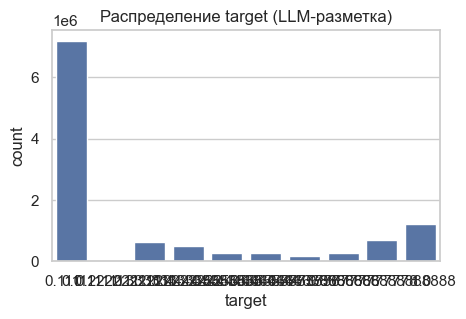

In [7]:
print(matches_llm['target'].value_counts(dropna=False))
print('\nДоля дубликатов:', matches_llm['target'].mean().round(4))

fig, ax = plt.subplots(figsize=(5,3))
sns.countplot(x=matches_llm['target'], ax=ax)
ax.set_title('Распределение target (LLM-разметка)')
plt.show()

## 3. Согласие ручной и LLM разметки

In [8]:
# Пересечение пар между источниками
pairs_h = set(map(tuple, matches[['id1','id2']].values))
pairs_l = set(map(tuple, matches_llm[['id1','id2']].values))
overlap = pairs_h & pairs_l
print(f'Ручных пар: {len(pairs_h):,}, LLM пар: {len(pairs_l):,}, пересечение: {len(overlap):,}')

Ручных пар: 365,654, LLM пар: 11,187,780, пересечение: 0


In [9]:
# Если есть пересечение — сравним метки (оценка шума LLM)
if overlap:
    o = list(overlap)
    h = matches.set_index(['id1','id2']).loc[o, 'target']
    l = matches_llm.set_index(['id1','id2']).loc[o, 'target']
    agree = (h.values == l.values).mean()
    print(f'Согласие меток: {agree:.4f}')
    print(pd.crosstab(h.values, l.values, rownames=['human'], colnames=['llm']))

## 4. Товары

In [10]:
# Полный items.parquet (3.8GB) читаем по частям; сначала — сэмпл для разведки текста
items_sample = pq.read_table(f'{DATA}/items.parquet').to_pandas().sample(200_000, random_state=RANDOM_STATE) if False else None
# Проще через pyarrow dataset с фильтром не выйдет для random — берём первые N row groups
pf = pq.ParquetFile(f'{DATA}/items.parquet')
batch = next(pf.iter_batches(batch_size=200_000))
items_sample = batch.to_pandas()
items_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   id          200000 non-null  int64
 1   name        200000 non-null  str  
 2   attributes  200000 non-null  str  
 3   category    200000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 140.5 MB


In [11]:
items_sample.head(10)

,id,name,attributes,category
0,9,"суппорт тормозной задний левый для опель вектра 1.6-2.5 1995 и далее, 2.0di-2.2tdi 1995 и далее, masterkit 77ak1494","{""бренд"":""masterkit"",""цвет товара"":""черный"",""страна-изготовитель"":""италия"",""материал"":""металлический сплав"",""количес...",Автотовары
1,25,sufix / тяга продольная верхняя l/r / зад. подв. тойота fj крузер 4.,"{""артикул производителя"":""si1117"",""оем номер"":""si-1117; c5449lr; 4871035050; 5798114sx; fq0966; ma125; ps5682; st487...",Автотовары
2,51,"haft шрус наружный, арт. ga0163","{""бренд"":""haft"",""oem-номер"":""495001m010; 495011m010; 495913x0b0; 49591a63a5"",""партномер (артикул производителя)"":""ga...",Автотовары
3,62,наконечник рулевой левый peugeot 405 85- stellox 5100767sx,"{""бренд"":""stellox"",""количество, штук"":""1"",""партномер (артикул производителя)"":""5100767sx"",""тип"":""наконечник рулевой""}",Автотовары
4,74,"carberry / 6pk905, ремень поликлиновой","{""артикул производителя"":""6pk905"",""длина упаковки"":""44 см"",""высота упаковки"":""5 см"",""ширина упаковки"":""10 см""}",Автотовары
5,77,рычаг передней подвески правый нижний mitsubishi airtrek i/lancer vii 03>13 miles db62039,"{""артикул производителя"":""db62039"",""бренд"":""miles"",""примечание"":""внешний вид изделия может отличаться от фотографий""...",Автотовары
6,108,труба гофрированная с внутренним плетением 54.5x120,"{""бренд"":""miles"",""партномер (артикул производителя)"":""hbfb545x120"",""тип"":""гофра глушителя""}",Автотовары
7,118,газонаполненные лампы alfas extreme weather 2800к h7,"{""длина упаковки"":""11 см"",""высота упаковки"":""12 см"",""ширина упаковки"":""7 см""}",Автотовары
8,176,startvolt / датчик давления топлива subaru tribeca (04-) outback (03-),"{""артикул производителя"":""fps0003"",""оем номер"":""ack12f0; fs11007; 314012f000; 0281006035; p8hy11803; p3hy11803; fzb1...",Автотовары
9,181,лампа 12v h19 60/55w pu43t-3 lynxauto super white 1 шт. l11960b,"{""бренд"":""lynxauto"",""типоразмер"":""h19"",""цоколь"":""pu43t-3"",""напряжение"":""12 в"",""количество"":""2""}",Автотовары


In [12]:
# Категории
vc = items_sample['category'].value_counts()
print('Число категорий:', vc.shape[0])
print(vc)

Число категорий: 1
category
Автотовары    200000
Name: count, dtype: int64


name: mean=62, p50=56, p95=126, max=398


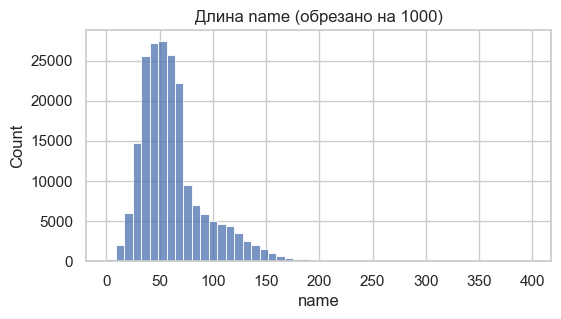

attributes: mean=409, p50=295, p95=1069, max=77625


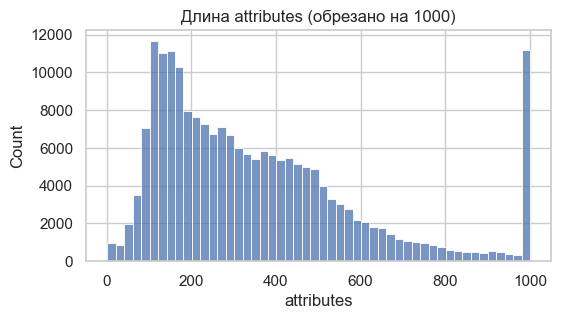

In [13]:
# Длины текстов
for col in ['name', 'attributes']:
    lens = items_sample[col].fillna('').str.len()
    print(f'{col}: mean={lens.mean():.0f}, p50={lens.quantile(.5):.0f}, p95={lens.quantile(.95):.0f}, max={lens.max()}')
    fig, ax = plt.subplots(figsize=(6,3))
    sns.histplot(lens.clip(upper=1000), bins=50, ax=ax)
    ax.set_title(f'Длина {col} (обрезано на 1000)')
    plt.show()

In [14]:
# Пропуски
items_sample.isna().mean()

id            0.0
name          0.0
attributes    0.0
category      0.0
dtype: float64

In [15]:
# Уникальность id в сэмпле
print('id уникальны в сэмпле:', items_sample['id'].is_unique)

id уникальны в сэмпле: True


## 5. Джойн пар с товарами: примеры дублей/не-дублей

In [16]:
# Товары ручной разметки маленькие (204MB) — грузим целиком
items_human = pd.read_parquet(f'{DATA}/items_human.parquet')
print(items_human.shape)
assert items_human['id'].is_unique

(711304, 4)


In [17]:
m = (matches
     .merge(items_human.add_suffix('_1'), left_on='id1', right_on='id_1', how='left')
     .merge(items_human.add_suffix('_2'), left_on='id2', right_on='id_2', how='left'))
print(m.shape)
m[['name_1', 'category_1', 'name_2', 'category_2', 'target']].head()

(365654, 11)


,name_1,category_1,name_2,category_2,target
0,очки с футляром-змейка fedrov мод. 1047 цвет 3 с линзами romeo 1.56 hmc/emi -2.00 рц 62-64,Аптека,"фотохромные очки с футляром-змейка fedrov мод. 1047 цвет 3 с линзами romeo 1.56 fast photocolor brown, hmc+ -3.00 рц...",Аптека,0.0
1,"зубная щетка r.o.c.s. black edition classic, черная/красная",Красота и гигиена,"зубная щетка r.o.c.s. red edition classic, средняя",Красота и гигиена,0.0
2,сандалии fre gamo,Обувь,fre gamo / сандалии,Обувь,0.0
3,"acuvue астигматические линзы oasys for astigmatism,ось:10_-0.75, 6 шт., -0.75 / 8.6/-0.75/10, 2 недели",Аптека,acuvue / контактные линзы acuvue oasys for astigmatism (6 линз) r 8.6 d +4.75 cyl -0.75 ax 10,Аптека,0.0
4,"дворцовый пуэр (5 лет), 500 г",Продукты питания,чайная линия ореховый пуэр (500 гр) вес: 500 гр,Продукты питания,0.0


In [18]:
# Совпадают ли категории внутри пары?
cat_match_rate = (m['category_1'] == m['category_2']).groupby(m['target']).mean()
print('Доля совпадения категорий в паре:\n', cat_match_rate)

Доля совпадения категорий в паре:
 target
0.0    1.0
1.0    1.0
dtype: float64


In [19]:
pd.set_option('display.max_colwidth', 300)
m[m.target == 1][['name_1', 'name_2', 'attributes_1', 'attributes_2']].sample(10, random_state=RANDOM_STATE)

,name_1,name_2,attributes_1,attributes_2
286459,"витекс / ""баня, сауна, массаж"" гель-душ+шампунь ''берёзовый'' 300 мл","витэкс шампунь баня-сауна-массаж березовый, 300 мл","{""состав"":""косметическая формула 100%"",""срок годности"":""1095"",""страна производства"":""беларусь"",""комплектация"":""1 шт"",""длина упаковки"":""10 см"",""высота упаковки"":""20 см"",""ширина упаковки"":""5 см"",""валюта"":""rub""}","{""способ применения"":""нанесите шампунь на влажные волосы, помассируйте до образования пены, тщательно до образования пены. при необходимости повторите"",""бренд"":""витэкс"",""состав"":""вода, лауретсульфат натрия, кокамидопропилбетаин, кокоамфодиацетат динатрия, гликольдистеарат, лаурет-4, амодиметикон..."
54312,londa professional / londa вlondesunlimited креативно-осветляющая пудра 400 г,"londa professional осветлитель для волос, 400 мл","{""вес товара без упаковки (г)"":""400 г"",""действие"":""осветление волос"",""срок годности"":""36 - месяцев"",""страна производства"":""германия"",""комплектация"":""пудра; обесцвечивающая пудра для волос"",""валюта"":""rub""}","{""способ применения"":""в зависимости от желаемой степени осветления и консистенции продукта смешайте креативную осветляющу пудру с окислителем в подходящей пропорции. пропорция смешивания от 1:1 до 1:3. рекомендуемая пропорция смешивания для легкого и наилучшего нанесения продукта - 1:2. максимал..."
196337,"pro plan / корм pro plan для собак мелких пород, лосось, 2 кг","сухой корм pro plan nature elements для взрослых собак мелких и карликовых пород с лососем, 2 кг","{""состав"":""кукуруза; мука; яичный порошок; лосось; рис; минеральные вещества и витамины"",""количество предметов в упаковке"":""1 шт"",""вес товара без упаковки (г)"":""2000 г"",""назначение корма"":""для поддержания жизненной энергии и иммунитета; для поддержания здоровья кожи и шерсти; для поддержания акт...","{""возраст животного"":""для взрослых"",""размер животного"":""малый"",""артикул"":""00000021072"",""бренд"":""pro plan"",""состав"":""с лососем: лосось высокого качества* (20%) (включая голову, кости, филе), рис* (14%), белок кукурузы, сухой белок лосося (10%), животные жиры, кукуруза*, растительная мука, высушен..."
28616,нитки для шитья бытовые 40/2 полиэстер 366м коричневый 10 штук,ideal / нитки бытовые для шитья 40/2 10шт.,"{""бренд"":""ideal"",""цвет товара"":""коричневый"",""название цвета"":""коричневый 549"",""образец цвета"":""https://cdn1.ozone.ru/s3/multimedia-o/6675757476.jpg"",""страна-изготовитель"":""китай"",""длина, м"":""366"",""состав ниток"":""полиэстер"",""комплектация"":""нитки ideal бытовые 40/2 полиэстер 366м цв.549 коричневый...","{""количество предметов в упаковке"":""10 шт.; набор ниток для шитья 10 катушек упаковки; нитки швейные полиэстер 366м"",""цвет"":""черный"",""комплектация"":""набор ниток для швей и ателье 10 предметов"",""валюта"":""rub""}"
255870,нож и решетка для мясорубки мастерица кэм-01,"нож и решетка для мясорубки midea mg-2777, mg-2753 (нож кв. 9мм + решетка д-53.5мм)","{""бренд"":""нет бренда"",""вид запчасти"":""решетка"",""список совместимых устройств"":""мастерица кэм-01"",""страна-изготовитель"":""китай"",""размеры, мм"":""кв. посадочного места 9х9 мм, д. решетки - 53,5 мм"",""материал"":""нержавеющая сталь"",""партномер"":""216.86"",""комплектация"":""в комплекте нож - 1 шт., решетка -...","{""тип"":""нож, перфорированный диск"",""тип устройства"":""мясорубка"",""производитель устройства"":""midea"",""назначение"":""для приготовления фарша"",""материал"":""металл"",""диаметр"":""53.5 мм""}"
168987,увлажнитель воздуха stadler form eva wi-fi,"увлажнитель воздуха stadler form e-008, белый","{""тип изделия"":""увлажнители воздуха"",""гарантия"":""1,0 г"",""глубина"":""196.0 мм"",""тип управления"":""механический"",""тип увлажнения"":""ультразвуковой"",""объем резервуара"":""6.3 л"",""расход воды"":""550.0 мл/ч"",""производительность"":""0.23 л/ч"",""площадь помещения"":""80.0 м²"",""объем помещения"":""200.0 м³"",""установ...","{

In [20]:
m[m.target == 0][['name_1', 'name_2', 'category_1', 'category_2']].sample(10, random_state=RANDOM_STATE)

,name_1,name_2,category_1,category_2
60283,чай зеленый принцесса ява традиционный 100г х 2шт,принцесса ява / чай принцесса ява традиционная зелёный 100г,Продукты питания,Продукты питания
141225,очки с футляром-змейка fedrov мод. 1047 цвет 3 с линзами romeo 1.499 cr-39 +4.50 рц 60-62,очки с футляром-змейка melorcsh мод. t37 цвет 5 с линзами romeo 1.499 cr-39 -2.25 рц 62-64,Аптека,Аптека
113079,диск тормозной stellox 60210025sx,stellox / тормозной диск задний (комплект 2 шт.) ниссан 60202252sx,Автотовары,Автотовары
25136,"promega label basic / этикетки самокл. promega label basic 28,5 мм / 30 шт. на лис","этикетки самоклеящиеся promegalabelbasic каучуковый клей, 52,5х29,7, 40 штук на листе а4, 100 листов в упаковке",Канцелярские товары,Канцелярские товары
323869,кроссовки new balance new balance 574,кроссовки new balance 574,Обувь,Обувь
50694,"acuvue астигматические линзы johnson & johnson 1 day oasys with hydraluxe for astigmatism 30 шт_120_-0.75, 30 шт., -0.50 / 8.5/-0.75/120, 1 день","контактные линзы acuvue oasys 1-day with hydraluxe for astigmatism, 30 шт., r 8,5, d +0,75, cyl: -1,75, aх: 90, 1 уп.",Аптека,Аптека
183864,"globen / глобус физический рельефный,210 мм","глобус физический рельефный, 210 мм",Канцелярские товары,Канцелярские товары
358988,солнцезащитный шампунь kemon actyva linfa solare shampoo velian actyva linfa solare shampoo velian,точечный крем для проблемной кожи yadah anti-t red zero spot cream - 1 шт,Красота и гигиена,Красота и гигиена
167630,kaizi очки солнцезащитные,очки солнцезащитные,Галантерея и аксессуары,Галантерея и аксессуары
23146,ferplast подставка под клетку для птиц regina белая,"подставка под клетку для птиц regina, katy коричневая",Товары для животных,Товары для животных


In [21]:
# Распределение таргета по категориям (важно для macro PR-AUC)
cat_target = m.groupby(m['category_1'])['target'].agg(['mean', 'count']).sort_values('count', ascending=False)
print(cat_target)

                             mean  count
category_1                              
Одежда                   0.117781  23357
Автотовары               0.174961  19010
Ювелирные изделия        0.123937  18695
Электроника              0.172742  18681
Мебель                   0.150060  18366
Обувь                    0.098737  18362
Аптека                   0.072628  18285
Продукты питания         0.270510  18284
Товары для животных      0.355829  18211
Строительство и ремонт   0.217048  18102
Галантерея и аксессуары  0.167649  17984
Музыкальные инструменты  0.221698  17817
Бытовая техника          0.359493  17814
Спорт и отдых            0.259638  17717
Хобби и творчество       0.463993  17677
Дом и сад                0.262206  17574
Детские товары           0.561984  17561
Бытовая химия            0.469316  17436
Канцелярские товары      0.338572  17435
Красота и гигиена        0.363473  17286


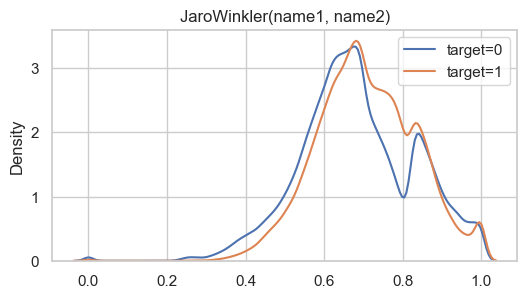

AUC этой одной фичи: 0.5531528357323758


In [22]:
# Грубая оценка разделимости: JaroWinkler сходство названий
try:
    from rapidfuzz.distance import JaroWinkler
except ImportError:
    raise SystemExit('pip install rapidfuzz')

sim = np.array([JaroWinkler.normalized_similarity(a, b) for a, b in zip(m['name_1'].fillna(''), m['name_2'].fillna(''))])
fig, ax = plt.subplots(figsize=(6,3))
for t in [0, 1]:
    sns.kdeplot(sim[m.target.values == t], label=f'target={t}', ax=ax)
ax.legend(); ax.set_title('JaroWinkler(name1, name2)')
plt.show()
print('AUC этой одной фичи:',
      ((sim[m.target.values==1][:,None] > sim[m.target.values==0]).sum() + 0.5*(sim[m.target.values==1][:,None]==sim[m.target.values==0]).sum())
      / ((m.target==1).sum()*(m.target==0).sum()))

## Выводы
Заполнить после прогона:
- Баланс классов в обоих источниках
- Согласие human/LLM разметки → стратегия работы с шумом
- Структура attributes (JSON? строка?)
- Разделимость простыми фичами